[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Tommy-Burns/easy-eo/blob/main/examples/04_timeseries/01_cloud_free_composite_and_trends.ipynb)

# Cloud-free composites and NDVI trends

A season of Sentinel-2 over one place, turned into two things a single scene cannot give you: one image with the clouds taken out, and a curve of how green each field got, week by week.

- **Data:** Sentinel-2 L2A from Microsoft Planetary Computer - 51 acquisitions over Dutch polder farmland, April to September 2023
- **Network: required.** This notebook queries a live catalog, so the numbers below are from the run committed here; re-running it fetches today's catalog and may differ slightly.
- **Requires:** `pip install "easy-eo[stac]"`

What it covers: `eeo.time_series`, `.map`, `.composite`, `.extract_at`, the four temporal reducers, and the two things a real catalog does that a tutorial usually hides - duplicate scenes and cloud that a scene-level filter cannot see.

In [1]:
# Running in Colab? Install Easy-EO. Does nothing anywhere else.
import sys

if "google.colab" in sys.modules:
    %pip install -q "easy-eo[stac]"

In [2]:
%matplotlib inline
import matplotlib.pyplot as plt

# Keeps the figures stored in this notebook small; raise it for print-quality output.
plt.rcParams["figure.dpi"] = 80

In [3]:
import eeo

eeo.show_versions()

Easy-EO version information
easy-eo            : 0.4.2
python             : 3.10.19
OS                 : Linux 7.0.0-34-generic
rasterio           : 1.4.3
GDAL               : 3.6.2
numpy              : 1.26.4
pandas             : 2.1.4
geopandas          : 1.1.1
matplotlib         : 3.10.6
xarray             : 2025.4.0
rioxarray          : 0.19.0
dask               : 2026.8.0
pystac-client      : 0.9.0
planetary-computer : 1.0.0


## The place and the question

Flevoland, in the Netherlands: polder farmland reclaimed from the sea, cropped intensively, and under one of Europe's cloudier skies. A 4 km box over it, and one field centre to follow through the season.

The question a single scene cannot answer: **when did each field green up, and how green did it get?** Every attempt to answer it from one image runs into the same wall - the one cloudless day you have may not be the day you care about.

In [4]:
# A 4 km box of polder farmland, and a field centre inside it (lon, lat).
AOI = (5.60, 52.05, 5.65, 52.085)
FIELD = (5.625, 52.0675)

results = eeo.stac_search(
    "sentinel-2-l2a",
    bbox=AOI,
    datetime="2023-04-01/2023-09-30",
    # Deliberately permissive. For a composite you *want* the cloudy scenes:
    # each one still sees the ground somewhere, and the mask sorts out where.
    cloud_cover=90,
)
results

/home/tommy/miniconda3/envs/easy-eo-env/lib/python3.10/site-packages/pystac_client/item_search.py:243: DoesNotConformTo: Server does not conform to QUERY
  warnings.warn(DoesNotConformTo("QUERY"))


<STACSearchResult: 92 items from 2023-04-02 to 2023-09-27 (sentinel-2-l2a)>

## What a catalog actually hands you

Ninety-two items for what is really about fifty acquisitions. Catalogs publish reprocessed versions of the same overpass, and both versions match a search. Left alone, a median composite would count those days twice.

Keeping the first item per acquisition date is enough here. (A wider box would also straddle two MGRS tiles, whose windows differ - `eeo.time_series(..., auto_align=True)` handles that, at the cost of resampling.)

In [5]:
one_per_date = {}
for item in results:
    one_per_date.setdefault(item.timestamp.date(), item)

scenes = list(one_per_date.values())
print(f"{len(results)} items in the catalog -> {len(scenes)} distinct acquisitions")
print("cloud cover reported per scene:", sorted(round(item.cloud_cover) for item in scenes)[:12], "...")

92 items in the catalog -> 51 distinct acquisitions
cloud cover reported per scene: [0, 0, 0, 0, 0, 1, 1, 2, 3, 4, 8, 12] ...


## One series, read once

`eeo.time_series` reads the same assets from every item and hands back an ordered, timestamped collection. Three things happen that are worth knowing:

- **Only the box is read.** Each asset is a full Sentinel-2 tile on the far end of an HTTP connection; what crosses the wire is the 4 km window.
- **The scenes are cached to disk** and reopened from there, so the series holds file handles rather than fifty windows of pixels - and the catalog's signed URLs, which expire, are read exactly once.
- **`SCL` comes along.** It is the scene-classification band, the thing that knows where the cloud is.

In [6]:
ts = eeo.time_series(scenes, assets=["B04", "B08", "SCL"])
ts

<EEOTimeSeries: 51 timesteps from 2023-04-02 to 2023-09-27, 3×402×358 uint16 EPSG:32631>

In [7]:
print("timesteps:", len(ts))
print("grid:", ts.shape, ts.crs)
print("bands:", ts.band_names)
print("first three dates:", [stamp.date().isoformat() for stamp in ts.timestamps[:3]])

timesteps: 51
grid: (402, 358) EPSG:32631
bands: ['B04', 'B08', 'SCL']
first three dates: ['2023-04-02', '2023-04-05', '2023-04-15']


## The trap: NDVI straight off the series

`.map` applies any Easy-EO operation to every timestep, unchanged - the same `ndvi` you would call on one scene. `.extract_at` then samples one pixel per timestep and returns a pandas `DataFrame` indexed by acquisition time.

Do it without masking and the result looks like a field that collapses and recovers every few days.

In [8]:
raw = ts.map(eeo.ndvi, red="B04", nir="B08", name="ndvi")
raw_trend = raw.extract_at(FIELD, crs="EPSG:4326")

raw_trend.head()

,ndvi
time,
2023-04-02 10:36:21.024000+00:00,0.533029
2023-04-05 10:50:31.024000+00:00,0.507321
2023-04-15 10:46:21.024000+00:00,0.224663
2023-04-17 10:36:29.024000+00:00,0.520185
2023-04-22 10:36:21.024000+00:00,0.110459


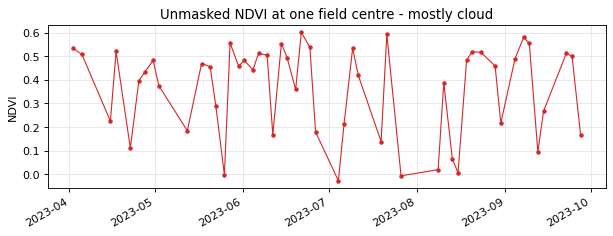

In [9]:
fig, ax = plt.subplots(figsize=(9, 3))
raw_trend["ndvi"].plot(ax=ax, marker="o", ms=3, lw=1, color="tab:red")
ax.set_ylabel("NDVI"); ax.set_xlabel("")
ax.set_title("Unmasked NDVI at one field centre - mostly cloud")
ax.grid(alpha=0.3)
plt.show()

Crops do not lose half their leaf area in two days and grow it back. Every plunge is a cloud passing over that pixel: bright in the red band, dark in the near-infrared, which is exactly what NDVI reads as bare ground.

## Masking the series

`mask_clouds` reads each scene's own `SCL` band and sets everything that is not a view of the ground to nodata. the plunges become **gaps**, because a pixel that was under cloud now says so instead of reporting a number.

In [10]:
masked = ts.map(eeo.mask_clouds)
clean = masked.map(eeo.ndvi, red="B04", nir="B08", name="ndvi")
clean_trend = clean.extract_at(FIELD, crs="EPSG:4326")

gaps = int(clean_trend["ndvi"].isna().sum())
print(f"{gaps} of {len(clean_trend)} acquisitions were cloudy over this pixel")
print(f"scatter: {raw_trend['ndvi'].std():.3f} unmasked against {clean_trend['ndvi'].std():.3f} masked")

26 of 51 acquisitions were cloudy over this pixel
scatter: 0.191 unmasked against 0.047 masked


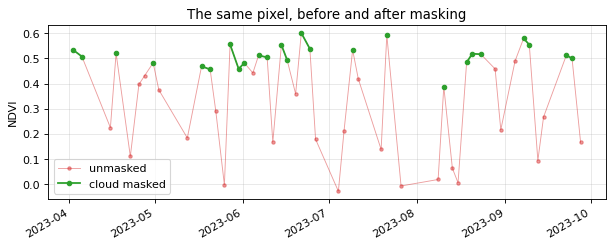

In [11]:
fig, ax = plt.subplots(figsize=(9, 3.2))
raw_trend["ndvi"].plot(ax=ax, marker="o", ms=3, lw=0.8, color="tab:red", alpha=0.45, label="unmasked")
clean_trend["ndvi"].plot(ax=ax, marker="o", ms=4, lw=1.6, color="tab:green", label="cloud masked")
ax.set_ylabel("NDVI"); ax.set_xlabel("")
ax.set_title("The same pixel, before and after masking")
ax.legend(); ax.grid(alpha=0.3)
plt.show()

That green line is a crop: bare soil in April, closing canopy through May and June, a peak around midsummer, harvest, then a green cover crop in September. It is the curve the red one was hiding.

The gaps are honest. A missing date is missing, not interpolated - and `NaN` is what pandas, matplotlib and every statistics library already know how to skip.

## The composite: one image from fifty

A trajectory answers *when*. For *where*, the series has to collapse into one raster - and the pixel that was clouded on one date was usually clear on another.

`.composite()` masks every timestep with its own quality band and takes the median across time, per pixel. The quality band is deliberately **not** in the result: it has done its work, and a median of scene-class numbers would be a class no classifier ever assigned.

In [12]:
clear = ts.composite()

print("bands:", clear.band_names, "- the SCL band has done its job and is gone")
print("covered by at least one clear acquisition:", f"{clear.clear_fraction():.1%}")
clear

bands: ['B04', 'B08'] - the SCL band has done its job and is gone
covered by at least one clear acquisition: 100.0%


<EEORasterDataset 2×402×358 float32 EPSG:32631 [B04, B08]>

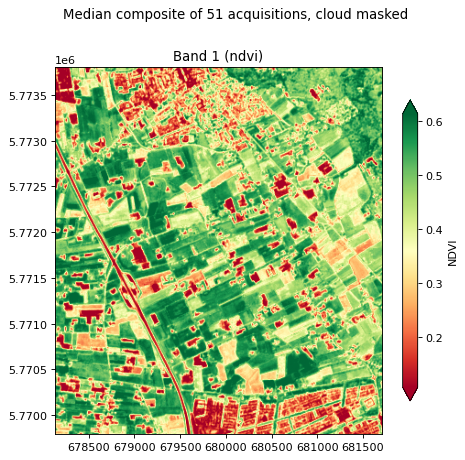

In [13]:
composite_ndvi = clear.ndvi(red="B04", nir="B08", name="ndvi")

composite_ndvi.plot_raster(
    cmap="RdYlGn",
    colorbar=True,
    colorbar_label="NDVI",
    title="Median composite of 51 acquisitions, cloud masked",
    figsize=(6, 6),
)

## What the composite buys, against one scene

The honest comparison is against what you would have done without a time series: pick the least cloudy day and work from it.

In [14]:
# How much of the box each acquisition actually saw, cheapest first: masking
# already happened above, so this is a read of the masked series.
seen = [float(scene.clear_fraction()) for scene in masked]

clearest = max(range(len(seen)), key=lambda i: seen[i])
# A half-clouded day is the interesting comparison: a wholly clouded one is a
# blank panel, and the composite fills it from its neighbours either way.
partly = min(range(len(seen)), key=lambda i: abs(seen[i] - 0.5))
print(f"clearest:      {ts.timestamps[clearest].date()} saw {seen[clearest]:.0%} of the box")
print(f"partly cloudy: {ts.timestamps[partly].date()} saw {seen[partly]:.0%}")
print(f"wholly clouded: {sum(1 for f in seen if f == 0)} of {len(seen)} acquisitions")

clearest:      2023-04-05 saw 100% of the box
partly cloudy: 2023-08-10 saw 50%
wholly clouded: 11 of 51 acquisitions


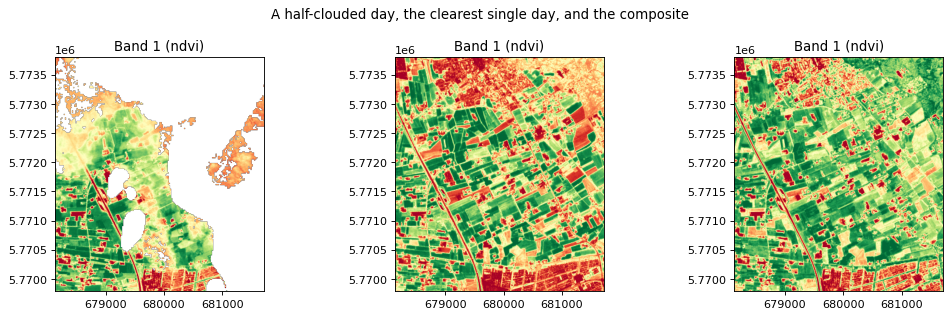

In [15]:
eeo.plot_raster(
    [
        masked[partly].ndvi(red="B04", nir="B08", name="ndvi"),
        masked[clearest].ndvi(red="B04", nir="B08", name="ndvi"),
        composite_ndvi,
    ],
    cmap="RdYlGn",
    ncols=3,
    figsize=(13, 4),
    title="A half-clouded day, the clearest single day, and the composite",
)

The first panel has holes where the cloud was, and those holes are the point: the composite fills each of them from an acquisition that saw through. Even the clearest single day is still one day, so whatever the crop was doing that morning is what you get. The composite is the season's typical state everywhere at once, assembled per pixel from whichever acquisitions saw it.

A wholly clouded acquisition contributes nothing and costs nothing: it is absent everywhere, and the median never sees it.

## Peak greenness, per pixel

The reducers are not only for compositing. `max()` over a masked NDVI series answers a different question for every pixel independently: *how green did this ever get?* - which separates a well-grown crop from a struggling one regardless of when each peaked.

A reducer collapses the time axis, so what it returns is one raster rather than a shorter series. Sampling that raster at the field we followed has to give the same answer as reducing that field's own trajectory - and it does.

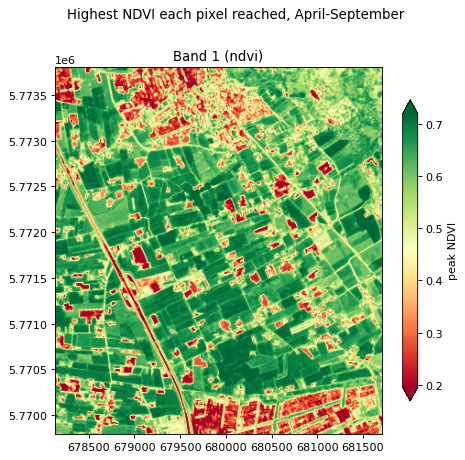

In [16]:
peak = clean.max()

peak.plot_raster(
    cmap="RdYlGn",
    colorbar=True,
    colorbar_label="peak NDVI",
    title="Highest NDVI each pixel reached, April-September",
    figsize=(6, 6),
)

In [17]:
# A reducer collapses the time axis, so what comes back is one raster, not a
# shorter series: `.to_array()` on it is indexed [band, row, col]. Sampling it
# at the field we followed must agree with that field's own trajectory - same
# pixel, same valid dates, same statistic.
from rasterio.warp import transform as warp_transform

fx, fy = (values[0] for values in warp_transform("EPSG:4326", clean.crs, [FIELD[0]], [FIELD[1]]))
season_median = clean.median().extract_value_at_coordinate((fx, fy))
season_peak = peak.extract_value_at_coordinate((fx, fy))

print(f"at this field, over the season: median {season_median:.3f}, peak {season_peak:.3f}")
print(f"the same from its trajectory:   median {clean_trend['ndvi'].median():.3f}, peak {clean_trend['ndvi'].max():.3f}")

at this field, over the season: median 0.513, peak 0.601
the same from its trajectory:   median 0.513, peak 0.601


## Practical notes

**Memory.** The reducers stream: they read one block of every timestep at a time, and the block shrinks as the series grows, so a reduction's peak does not depend on how many acquisitions it covers. Masking is the expensive half - `mask_clouds` reads a whole scene - so for a long series of large scenes, write the masked timesteps out instead of holding them:

```python
clear = ts.composite(mask_dir="masked/", save_path="composite.tif")
```

**Keeping the reads.** Signed catalog URLs expire, cached GeoTIFFs do not. Point the series at a directory you keep and the same scenes are reusable tomorrow:

```python
ts = eeo.time_series(scenes, assets=["B04", "B08", "SCL"], cache="scenes/")
```

**January 2022.** Sentinel-2 processing baseline 04.00 shifted the stored values by -1000 DN. Easy-EO reads stored values rather than decoding reflectance, so a series that spans 25 January 2022 mixes two conventions - it warns when it sees one. Keep a series on one side of that date, or use scenes reprocessed to a single baseline.

**Wider areas.** A box that crosses an MGRS tile boundary draws items whose windows differ; pass `auto_align=True` to warp them onto the first timestep's grid, or `auto_reproject=True` if the tiles are in different UTM zones.

## Where next

- [02_data_access/02_stac_search_and_load](../02_data_access/02_stac_search_and_load.ipynb) - searching and loading in more detail, including geometries and signed URLs
- [03_real_world/02_vegetation_health_and_drought](../03_real_world/02_vegetation_health_and_drought.ipynb) - the index library on a single scene
- [01_fundamentals/06_statistics_and_extraction](../01_fundamentals/06_statistics_and_extraction.ipynb) - sampling and statistics on one raster
- The [Easy-EO documentation](https://easy-eo.readthedocs.io/) - see the Time Series module reference for every argument these calls take